# Posterior for E. coli local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load bacillus gene data and clonal tree.

In [3]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/ecoli/ecoli_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                          ______________________________ 8
                                         |
  _______________________________________|          ____________________ 0
 |                                       |         |
 |                                       |         |                    , 21
 |                                       |_________|    ________________|
 |                                                 |   |                , 2
 |                                                 |   |                |
 |                                                 |___|                | 26
 |                                                     |
 |                                                     |   _____________ 7
 |                                                     |__|
 |                                                        |_____________ 10
 |
_|                                                                    __ 20
 |                           

In [4]:
x_obs_info_table = pd.read_csv("../data/ecoli/ecoli_block_info.csv", index_col=0)
x_obs_info_table.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True


In [5]:
drop_col = range(16, 32)

In [6]:
x_obs_df = pd.read_csv("../data/ecoli/ecoli_block_summary_stats.csv", header=None)
x_obs_np = x_obs_df.to_numpy()
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([836, 30]), torch.float32)

### Delete observations with no signal

In [7]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True
...,...,...,...,...
761_0,5476,1504811,1510286,True
761_1,5475,1510287,1515761,True
762,4170,1541972,1546141,True


In [8]:
too_large_length = np.where(x_obs_info_table['Gene_Length'] > 10000)[0]
too_large_length

array([], dtype=int64)

In [9]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

Ignore the observations that have too large gene length. But there is no observations with no signal.

## Load simulation data

In [10]:
theta1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/ecoli/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

x = np.vstack([x1, x2, x3, x4, x5, x6, x7, x8, x9, x10])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10]])

print(theta.shape, x.shape)

(57100, 3) (57100, 30)


In [11]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [12]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 5 is outside the range of simulated data.
Observation 22 is outside the range of simulated data.
Observation 31 is outside the range of simulated data.
Observation 38 is outside the range of simulated data.
Observation 57 is outside the range of simulated data.
Observation 60 is outside the range of simulated data.
Observation 63 is outside the range of simulated data.
Observation 108 is outside the range of simulated data.
Observation 120 is outside the range of simulated data.
Observation 136 is outside the range of simulated data.
Observation 146 is outside the range of simulated data.
Observation 149 is outside the range of simulated data.
Observation 162 is outside the range of simulated data.
Observation 164 is outside the range of simulated data.
Observation 261 is outside the range of simulated data.
Observation 308 is outside the range of simulated data.
Observation 345 is outside the range of simulated data.
Observation 362 is outside the range of simulated data.


In [13]:
len(ignore_indices), len(no_segregation), len(out_stats)

(35, 0, 35)

In [14]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [15]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [16]:
for i in range(30):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 11
Index 9: 5
Index 10: 0
Index 11: 0
Index 12: 15
Index 13: 6
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 35
Index 23: 21
Index 24: 0
Index 25: 14
Index 26: 0
Index 27: 0
Index 28: 0
Index 29: 0


## NPE

### Create prior to pass range knowledge to NPE

In [17]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.2]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [18]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [19]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [20]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500,
    training_batch_size=100,
    learning_rate=0.0001,
    stop_after_epochs=20,
    clip_max_norm=None
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [8, 9, 10, 11, 12, 13, 16, 20, 25, 26, 27, 28] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 117 epochs.

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\potentials\posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


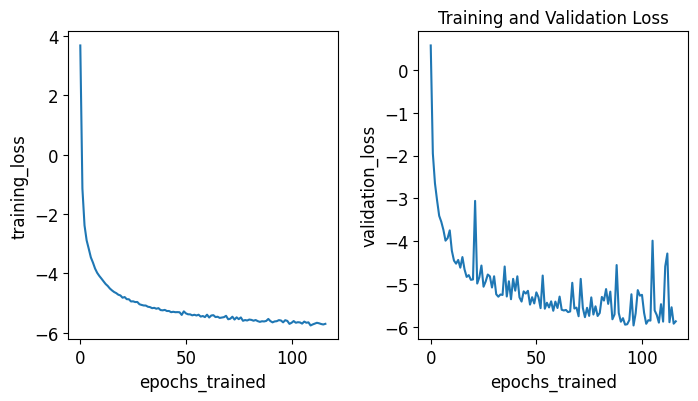

In [21]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [22]:
save_path = "../data/ecoli/trained_npe_posterior.pt"

torch.save(
    {
        "posterior": posterior,
        "sbi_version": sbi.__version__,
        "seed": seed,
        "learning_rate": 0.0001,
        "max_num_epochs": 500,
    },
    save_path,
)

In [23]:
# checkpoint = torch.load(save_path, map_location="cpu")
# loaded_posterior = checkpoint["posterior"]

### Plug in observation data to get posterior

In [24]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(836, 1000, 3)

In [25]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


C:\Users\u2008181\AppData\Local\Temp\ipykernel_8936\3530236854.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


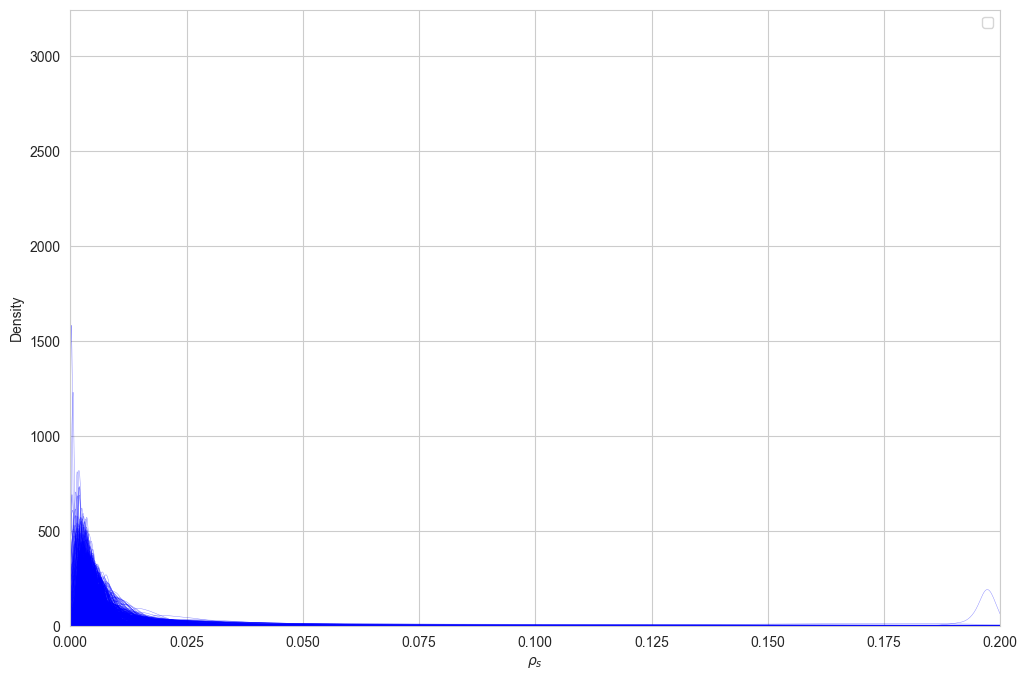

In [26]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_8936\4043880167.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


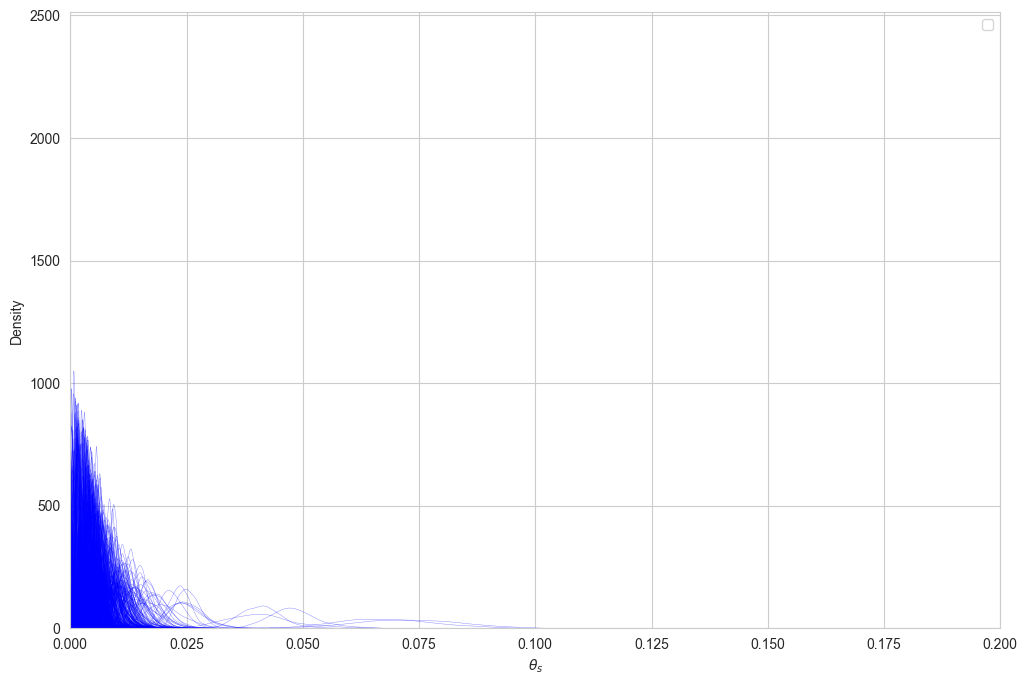

In [27]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue
    sns.kdeplot(theta_post[i, :, 1], color='blue', linewidth=0.3, alpha=0.5)
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

### Plot bar plots by position

In [28]:
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
0,1200,605790,606989,True
1,1724,614003,615726,True
2,4601,616186,620786,True
3,6950,606990,613939,True
4,3797,601974,605770,True
...,...,...,...,...
761_0,5476,1504811,1510286,True
761_1,5475,1510287,1515761,True
762,4170,1541972,1546141,True


In [43]:
plot_xlim = [0.0, 5000000.0]
samples_x = x_obs_info_table['Start_pos'].values

In [44]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape, posterior_median.shape

((836,), (836,))

In [45]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((836,), (836,))

In [46]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [47]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.004967502783983946)

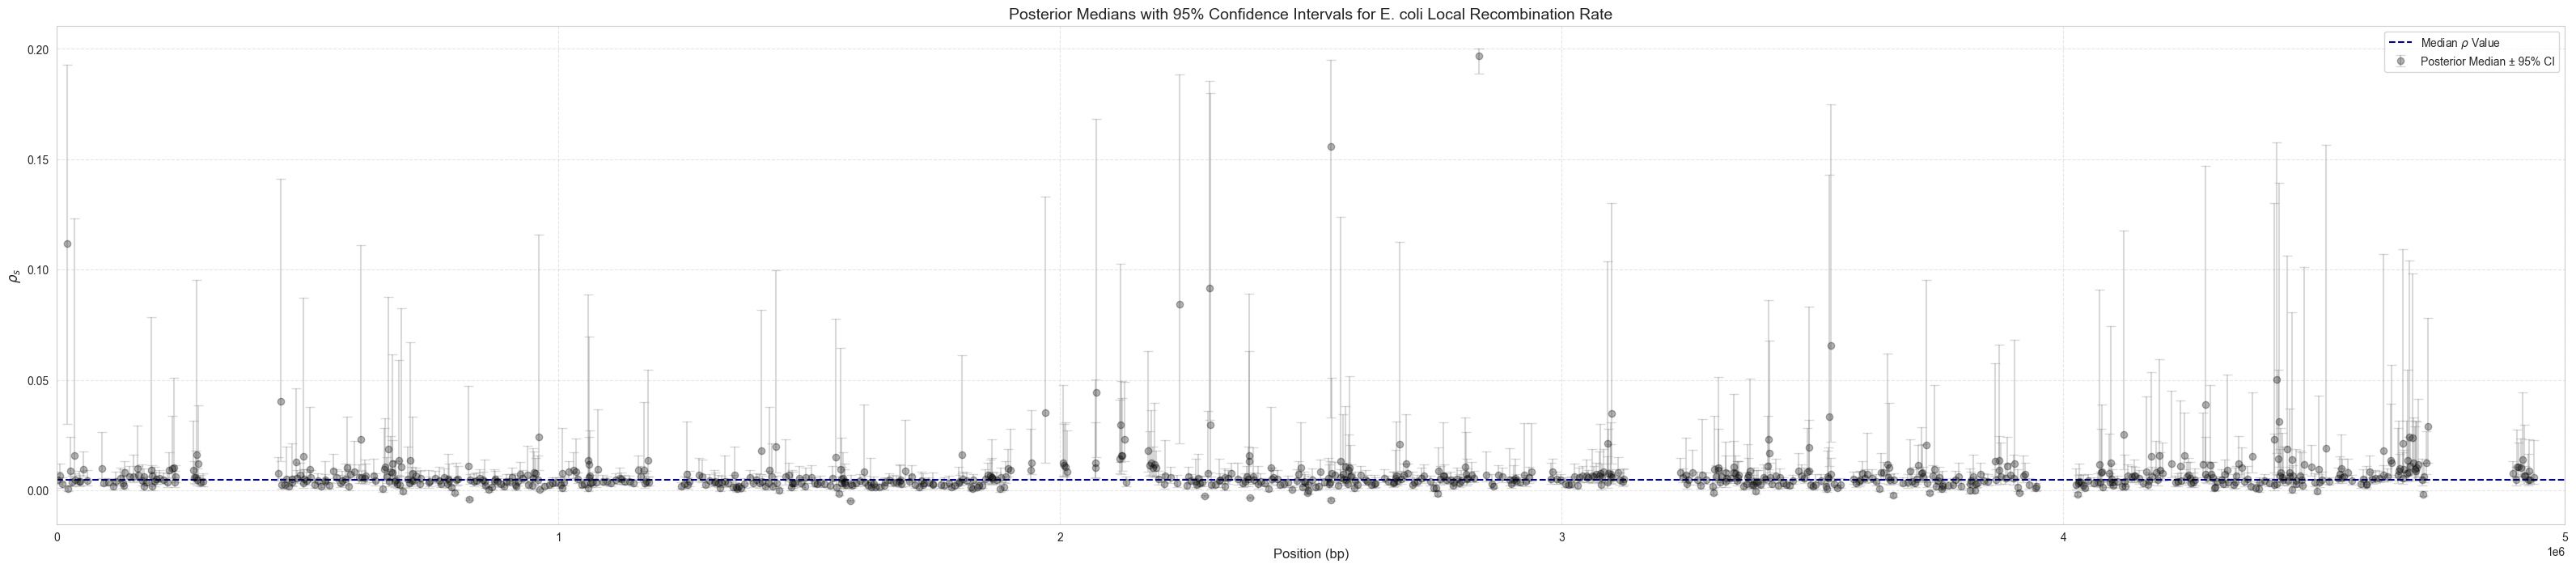

In [48]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=median_rho, color='darkblue', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [49]:
posterior_median_theta = np.median(theta_post[:, :, 1], axis=1)
posterior_median_theta.shape, posterior_median_theta.shape

((836,), (836,))

In [50]:
ci_lower_bounds_theta = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_theta = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_theta.shape, ci_upper_bounds_theta.shape

((836,), (836,))

In [51]:
lower_errors_theta = posterior_median_theta - ci_lower_bounds_theta
upper_errors_theta = ci_upper_bounds_theta - posterior_median_theta
yerr_theta = [lower_errors_theta, upper_errors_theta]

In [52]:
median_theta = np.median(posterior_median_theta)
median_theta

np.float64(0.00427816400770098)

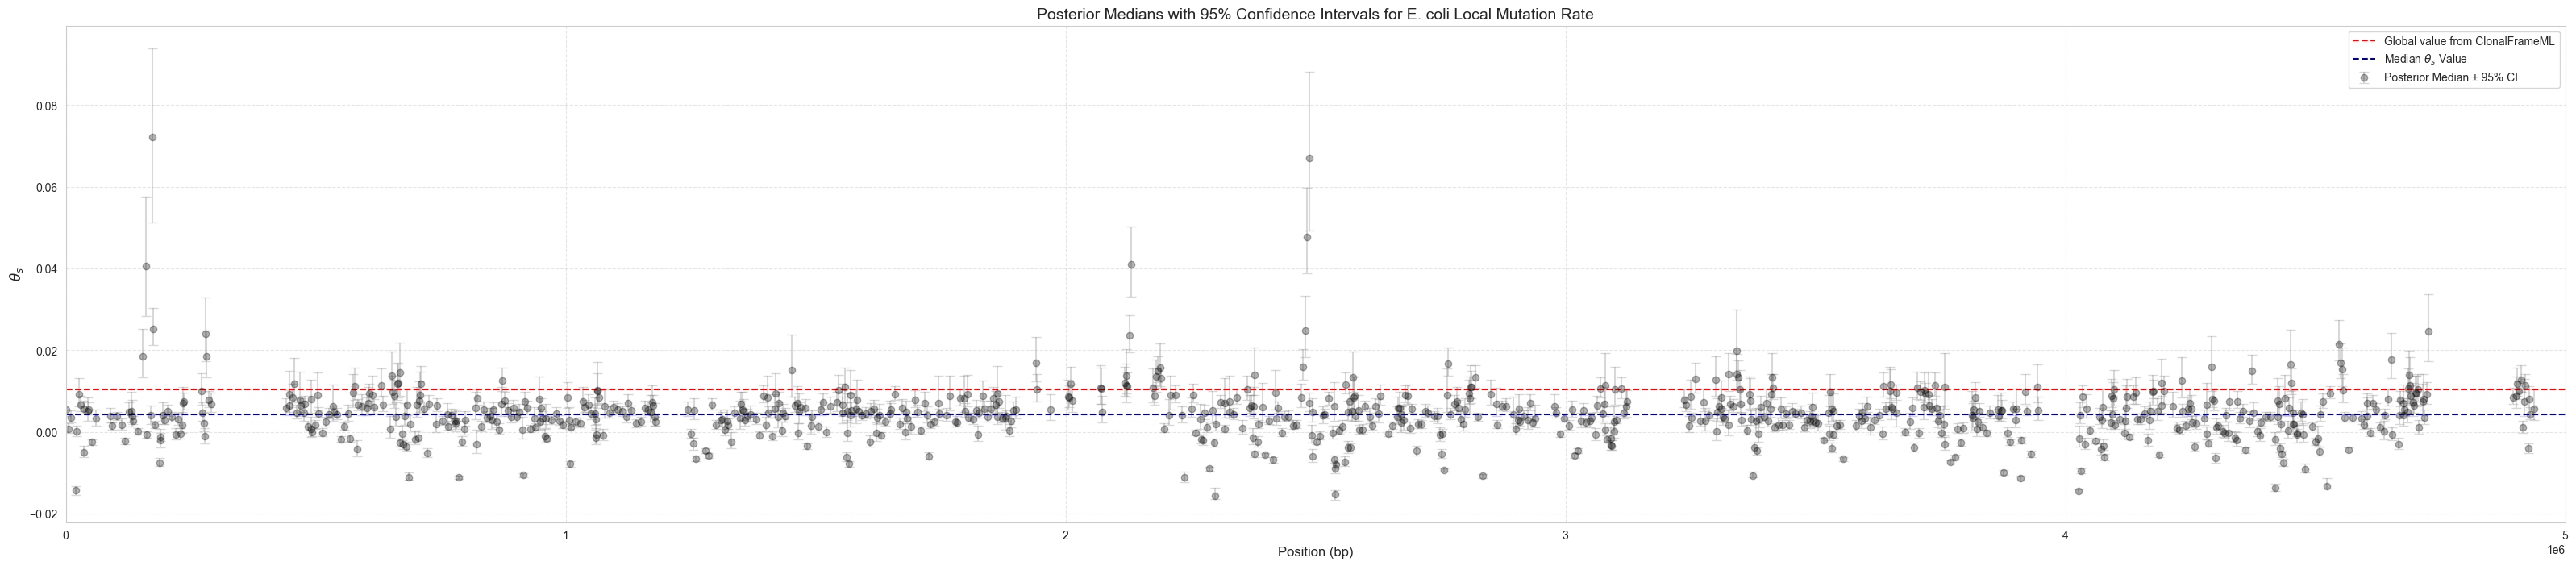

In [53]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, alpha=0.3,
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Local Mutation Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\theta_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.01033768239616971, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_theta, color='darkblue', linestyle='dashed', label=r'Median $\theta_s$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [54]:
samples_l = x_obs_info_table['Gene_Length'].values
samples_l.shape

(836,)

In [55]:
posterior_l_median = np.median(theta_post[:, :, 2], axis=1)
posterior_l_median.shape

(836,)

In [56]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 2], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 2], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((836,), (836,))

In [57]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

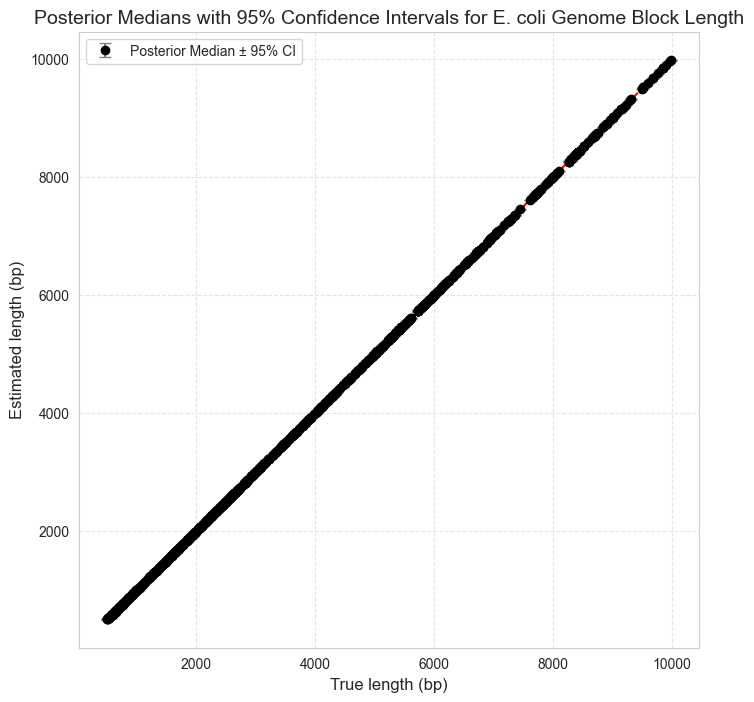

In [58]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for E. coli Genome Block Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

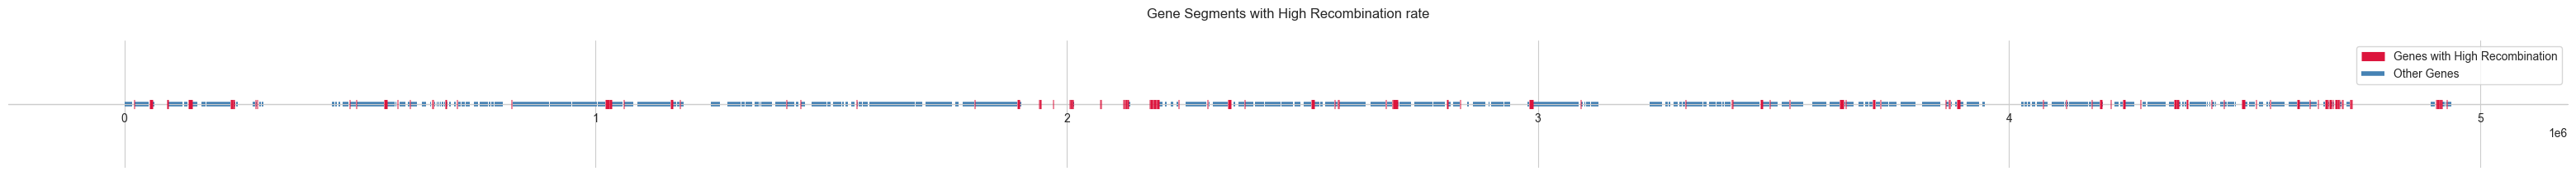

In [59]:
y_level = 0
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends   = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)

high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

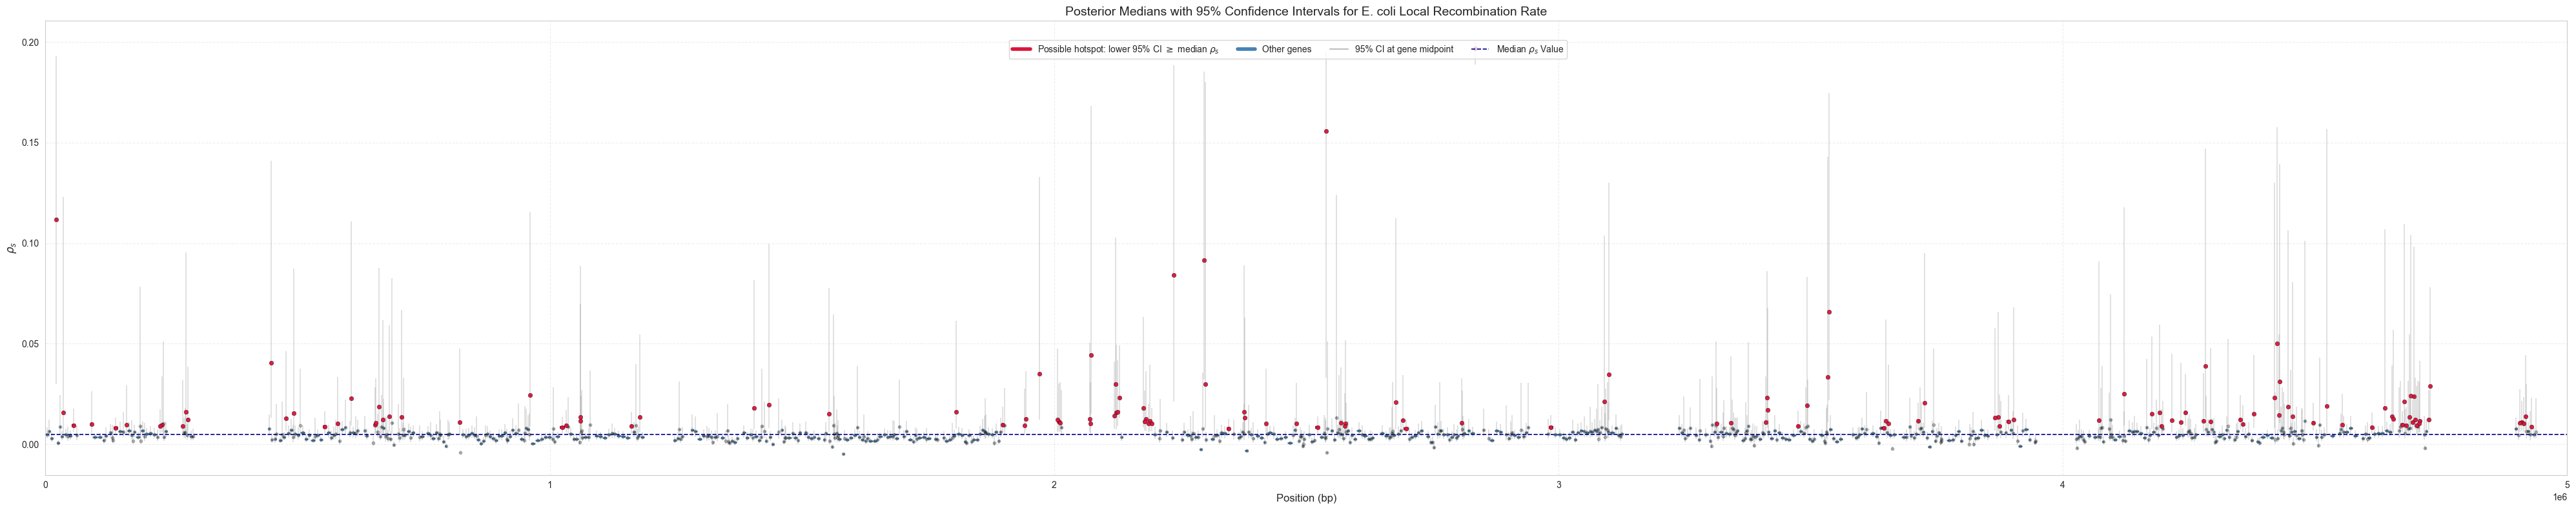

In [60]:
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median)
is_hotspot = ci_lower_bounds >= median_rho
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds,
    ci_upper_bounds,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
# ax.axhline(
#     y=0.077,
#     color='red',
#     linestyle='dashed',
#     linewidth=1.2,
#     label='Ansari and Didelot (2014)',
#     zorder=2,
# )
# ax.axhline(
#     y=0.017,
#     color='green',
#     linestyle='dashed',
#     linewidth=1.2,
#     label='Didelot et al. (2010)',
#     zorder=2,
# )
ax.axhline(
    y=median_rho,
    color='darkblue',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\rho_s$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for E. coli Local Recombination Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\rho_s$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds))
y_max = np.nanmax(ci_upper_bounds)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\rho_s$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

reference_handles, reference_labels = ax.get_legend_handles_labels()
legend_handles = [hotspot_handle, other_handle, ci_handle] + reference_handles
legend_labels = [handle.get_label() for handle in legend_handles]

# A figure-level legend centered below the title.
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.925),
    ncol=len(legend_handles),
    fontsize=10,
    frameon=True,
)

# Reserve the upper portion of the figure for the title and legend.
fig.tight_layout(rect=[0, 0, 1, 0.83])

plt.tight_layout()
plt.show()

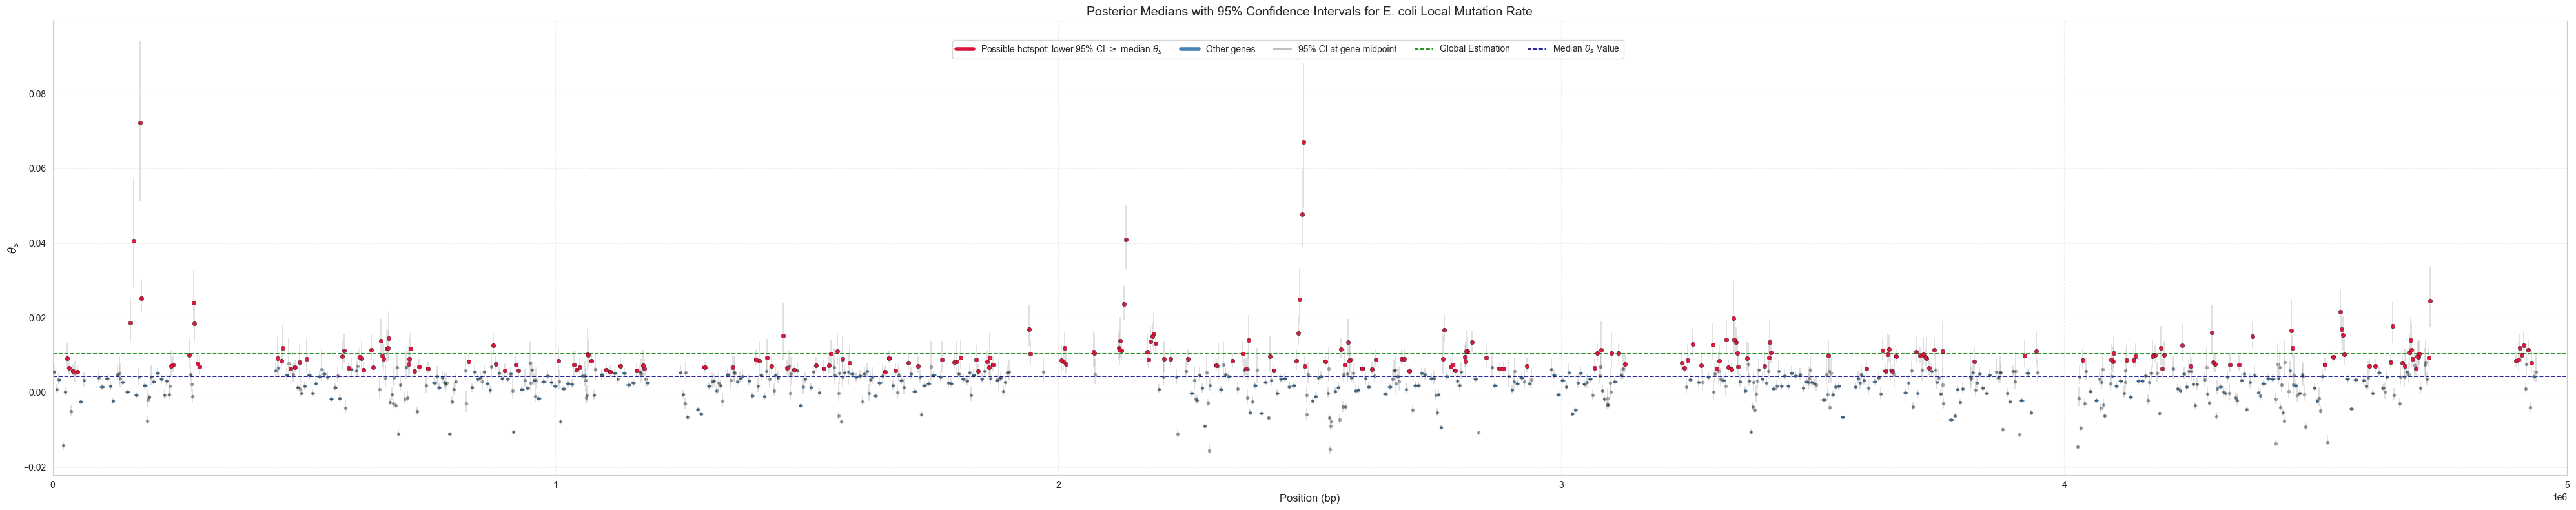

In [61]:
gene_starts = np.delete(x_obs_info_table['Start_pos'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos'].values, no_signal_id)
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median_theta)
is_hotspot = ci_lower_bounds_theta >= median_theta
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds_theta,
    ci_upper_bounds_theta,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
# ax.axhline(
#     y=0.0528,
#     color='red',
#     linestyle='dashed',
#     linewidth=1.2,
#     label='Ansari and Didelot (2014)',
#     zorder=2,
# )
ax.axhline(
    y=0.01033768239616971,
    color='green',
    linestyle='dashed',
    linewidth=1.2,
    label='Global Estimation',
    zorder=2,
)
ax.axhline(
    y=median_theta,
    color='darkblue',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\theta_s$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for E. coli Local Mutation Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\theta_s$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds_theta))
y_max = np.nanmax(ci_upper_bounds_theta)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\theta_s$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

reference_handles, reference_labels = ax.get_legend_handles_labels()
legend_handles = [hotspot_handle, other_handle, ci_handle] + reference_handles
legend_labels = [handle.get_label() for handle in legend_handles]

# A figure-level legend centered below the title.
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.925),
    ncol=len(legend_handles),
    fontsize=10,
    frameon=True,
)

# Reserve the upper portion of the figure for the title and legend.
fig.tight_layout(rect=[0, 0, 1, 0.83])

plt.tight_layout()
plt.show()

In [87]:
"""Distance-aware two-state HMM for chromosome hotspot detection.

Model
-----
For ordered genes g = 1, ..., G:

    z_g in {0=background, 1=hotspot}
    y_g | z_g=k ~ Normal(mu_k, sigma_k^2 + v_g)

where y_g and v_g are the mean and variance of the gene's NPE posterior
on the log-rate scale. The hotspot mean is constrained to exceed the
background mean.

State changes follow a continuous-time Markov chain along genomic distance:

    Q = [[-alpha, alpha],
         [ beta, -beta]]

and the transition matrix over distance d is exp(Q*d). Positions are
internally converted to a configurable distance unit (1 Mb by default).

This is a practical uncertainty-aware approximation: an NPE posterior is
not formally an observation likelihood. For a fully coherent hierarchical
analysis, replace the Gaussian emissions with prior-corrected NPE density
ratios q(theta|s)/p0(theta), a neural likelihood, or a ratio estimator.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import numpy as np
from numpy.typing import ArrayLike
from scipy.optimize import minimize
from scipy.special import expit, logsumexp
from scipy.stats import norm


_EPS = 1e-12

In [88]:
def _softplus(x: float | np.ndarray) -> float | np.ndarray:
    return np.logaddexp(0.0, x)


def _inv_softplus(y: float | np.ndarray) -> float | np.ndarray:
    y = np.maximum(y, 1e-10)
    return y + np.log(-np.expm1(-y))


@dataclass
class HotspotHMMResult:
    positions: np.ndarray
    log_rate_mean: np.ndarray
    log_rate_variance: np.ndarray
    hotspot_probability: np.ndarray
    viterbi_state: np.ndarray
    background_mean: float
    hotspot_mean: float
    background_sd: float
    hotspot_sd: float
    background_to_hotspot_rate: float
    hotspot_to_background_rate: float
    expected_background_length: float
    expected_hotspot_length: float
    log_likelihood: float
    distance_unit_bp: float
    optimizer_success: bool
    optimizer_message: str

    @property
    def fold_enrichment(self) -> float:
        """Estimated hotspot/background fold change on the original scale."""
        return float(np.exp(self.hotspot_mean - self.background_mean))

    def hotspot_calls(self, probability_threshold: float = 0.9) -> np.ndarray:
        return self.hotspot_probability >= probability_threshold

    def segments(self, probability_threshold: float = 0.9) -> list[dict]:
        """Return contiguous called segments; boundaries are gene positions."""
        called = self.hotspot_calls(probability_threshold)
        segments: list[dict] = []
        start = None

        for i, is_hot in enumerate(called):
            if is_hot and start is None:
                start = i
            if start is not None and (not is_hot or i == len(called) - 1):
                end = i if is_hot and i == len(called) - 1 else i - 1
                p = self.hotspot_probability[start : end + 1]
                segments.append(
                    {
                        "start_index": start,
                        "end_index": end,
                        "start_position": float(self.positions[start]),
                        "end_position": float(self.positions[end]),
                        "n_genes": end - start + 1,
                        "mean_hotspot_probability": float(p.mean()),
                        "min_hotspot_probability": float(p.min()),
                    }
                )
                start = None
        return segments

    def plot_states(
        self,
        probability_threshold: float = 0.90,
        position_unit_bp: float = 1e6,
        position_unit_name: str = "Mb",
        rate_label: str = "Recombination rate",
        figsize: tuple[float, float] = (12.0, 8.0),
        save_path: Optional[str] = None,
        dpi: int = 300,
    ):
        """Plot gene-level rates, hotspot probabilities, and HMM states.

        The top panel shows posterior geometric means and approximate 95%
        intervals. The middle panel shows smoothed hotspot probabilities.
        The bottom panel shows the Viterbi state path along physical position.

        Returns
        -------
        fig, axes
            Matplotlib figure and the three axes.
        """
        if not 0.0 <= probability_threshold <= 1.0:
            raise ValueError("probability_threshold must be between 0 and 1")
        if position_unit_bp <= 0:
            raise ValueError("position_unit_bp must be positive")

        import matplotlib.pyplot as plt
        from matplotlib.lines import Line2D

        x = self.positions / position_unit_bp
        state = self.viterbi_state.astype(int)
        p_hot = self.hotspot_probability
        log_sd = np.sqrt(self.log_rate_variance)
        rate = np.exp(self.log_rate_mean)
        lower = np.exp(self.log_rate_mean - 1.96 * log_sd)
        upper = np.exp(self.log_rate_mean + 1.96 * log_sd)

        colors = np.where(state == 1, "#d62728", "#4c78a8")
        fig, axes = plt.subplots(
            3,
            1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": [3.2, 2.0, 0.8], "hspace": 0.08},
        )
        ax_rate, ax_prob, ax_state = axes

        # Shade Viterbi hotspot regions using midpoint boundaries between genes.
        edges = np.empty(len(x) + 1)
        edges[1:-1] = (x[:-1] + x[1:]) / 2.0
        edges[0] = x[0] - (x[1] - x[0]) / 2.0
        edges[-1] = x[-1] + (x[-1] - x[-2]) / 2.0
        for i, is_hot in enumerate(state):
            if is_hot:
                for ax in (ax_rate, ax_prob, ax_state):
                    ax.axvspan(edges[i], edges[i + 1], color="#d62728", alpha=0.10, lw=0)

        ax_rate.vlines(x, lower, upper, color=colors, alpha=0.38, linewidth=1.0)
        ax_rate.scatter(x, rate, c=colors, s=25, edgecolor="white", linewidth=0.4, zorder=3)
        ax_rate.axhline(
            np.exp(self.background_mean),
            color="#4c78a8",
            linestyle="--",
            linewidth=1.4,
            label="Estimated background mean",
        )
        ax_rate.axhline(
            np.exp(self.hotspot_mean),
            color="#d62728",
            linestyle="--",
            linewidth=1.4,
            label="Estimated hotspot mean",
        )
        ax_rate.set_yscale("log")
        ax_rate.set_ylabel(rate_label)
        ax_rate.set_title(
            f"Distance-aware HMM: background vs hotspot "
            f"({self.fold_enrichment:.2f}x estimated enrichment)"
        )
        ax_rate.grid(alpha=0.2)
        ax_rate.legend(frameon=False, loc="best")

        ax_prob.plot(x, p_hot, color="#222222", linewidth=1.2)
        ax_prob.scatter(x, p_hot, c=colors, s=22, zorder=3)
        ax_prob.fill_between(
            x,
            probability_threshold,
            p_hot,
            where=p_hot >= probability_threshold,
            color="#d62728",
            alpha=0.25,
            interpolate=True,
        )
        ax_prob.axhline(
            probability_threshold,
            color="#d62728",
            linestyle="--",
            linewidth=1.1,
            label=f"Calling threshold = {probability_threshold:.2f}",
        )
        ax_prob.set_ylim(-0.03, 1.03)
        ax_prob.set_ylabel("P(hotspot)")
        ax_prob.grid(alpha=0.2)
        ax_prob.legend(frameon=False, loc="best")

        ax_state.step(x, state, where="mid", color="#333333", linewidth=1.3)
        ax_state.scatter(x, state, c=colors, s=22, zorder=3)
        ax_state.set_yticks([0, 1], labels=["Background", "Hotspot"])
        ax_state.set_ylim(-0.45, 1.45)
        ax_state.set_ylabel("Status")
        ax_state.set_xlabel(f"Chromosome position ({position_unit_name})")
        ax_state.grid(axis="x", alpha=0.2)

        state_legend = [
            Line2D([0], [0], marker="o", color="none", markerfacecolor="#4c78a8",
                   markeredgecolor="white", markersize=7, label="Background gene"),
            Line2D([0], [0], marker="o", color="none", markerfacecolor="#d62728",
                   markeredgecolor="white", markersize=7, label="Hotspot gene"),
        ]
        ax_state.legend(handles=state_legend, frameon=False, loc="upper right", ncol=2)

        fig.align_ylabels(axes)
        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        return fig, axes


class DistanceAwareHotspotHMM:
    """Two-state continuous-distance HMM with uncertainty-aware emissions.

    Parameters
    ----------
    distance_unit_bp
        Unit used for transition rates. With 1e6, alpha and beta are rates
        per Mb, and expected segment lengths are reported in base pairs.
    min_log_fold
        Minimum separation between hotspot and background means on the
        natural-log scale. For a minimum two-fold effect, use np.log(2).
    n_starts
        Number of optimization restarts.
    random_state
        Seed for reproducible initialization.
    """

    def __init__(
        self,
        distance_unit_bp: float = 1e6,
        min_log_fold: float = 0.0,
        n_starts: int = 8,
        random_state: Optional[int] = 1,
    ) -> None:
        if distance_unit_bp <= 0:
            raise ValueError("distance_unit_bp must be positive")
        if min_log_fold < 0:
            raise ValueError("min_log_fold must be non-negative")
        if n_starts < 1:
            raise ValueError("n_starts must be at least 1")

        self.distance_unit_bp = float(distance_unit_bp)
        self.min_log_fold = float(min_log_fold)
        self.n_starts = int(n_starts)
        self.rng = np.random.default_rng(random_state)
        self.result_: Optional[HotspotHMMResult] = None

    @staticmethod
    def summarize_npe_samples(
        posterior_samples: ArrayLike,
        rates_are_logged: bool = False,
        variance_floor: float = 1e-6,
    ) -> tuple[np.ndarray, np.ndarray]:
        """Reduce NPE samples to per-gene log-rate means and variances.

        posterior_samples must have shape (n_genes, n_draws). If joint NPE
        samples contain both recombination and mutation rates, pass one
        parameter slice at a time, e.g. samples[:, :, 0].
        """
        samples = np.asarray(posterior_samples, dtype=float)
        if samples.ndim != 2:
            raise ValueError("posterior_samples must have shape (genes, draws)")
        if samples.shape[1] < 2:
            raise ValueError("At least two posterior draws per gene are required")
        if not np.all(np.isfinite(samples)):
            raise ValueError("posterior_samples contains non-finite values")

        if rates_are_logged:
            log_samples = samples
        else:
            if np.any(samples <= 0):
                raise ValueError("Unlogged rate samples must all be positive")
            log_samples = np.log(samples)

        means = log_samples.mean(axis=1)
        variances = log_samples.var(axis=1, ddof=1)
        return means, np.maximum(variances, variance_floor)

    @staticmethod
    def _validate_and_sort(
        positions: ArrayLike,
        log_rate_mean: ArrayLike,
        log_rate_variance: ArrayLike,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        x = np.asarray(positions, dtype=float).reshape(-1)
        y = np.asarray(log_rate_mean, dtype=float).reshape(-1)
        v = np.asarray(log_rate_variance, dtype=float).reshape(-1)

        if not (len(x) == len(y) == len(v)):
            raise ValueError("positions, means, and variances must have equal length")
        if len(x) < 3:
            raise ValueError("At least three genes are required")
        if not (np.all(np.isfinite(x)) and np.all(np.isfinite(y)) and np.all(np.isfinite(v))):
            raise ValueError("Inputs contain non-finite values")
        if np.any(v < 0):
            raise ValueError("Posterior variances cannot be negative")

        order = np.argsort(x)
        x, y, v = x[order], y[order], v[order]
        if np.any(np.diff(x) <= 0):
            raise ValueError("Gene positions must be unique")
        return x, y, np.maximum(v, 1e-10)

    @staticmethod
    def _transition_matrix(distance: float, alpha: float, beta: float) -> np.ndarray:
        """Closed-form exp(Q*d) for a two-state continuous-time chain."""
        total = alpha + beta
        stationary_hot = alpha / total
        stationary_bg = beta / total
        decay = np.exp(-total * distance)
        return np.array(
            [
                [stationary_bg + stationary_hot * decay, stationary_hot * (1.0 - decay)],
                [stationary_bg * (1.0 - decay), stationary_hot + stationary_bg * decay],
            ]
        )

    def _unpack(self, raw: np.ndarray) -> tuple[float, float, float, float, float, float]:
        mu0 = raw[0]
        mu1 = mu0 + self.min_log_fold + _softplus(raw[1])
        sigma0 = np.exp(raw[2])
        sigma1 = np.exp(raw[3])
        alpha = np.exp(raw[4])
        beta = np.exp(raw[5])
        return mu0, mu1, sigma0, sigma1, alpha, beta

    def _components(
        self,
        raw: np.ndarray,
        y: np.ndarray,
        v: np.ndarray,
        distances: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        mu0, mu1, sigma0, sigma1, alpha, beta = self._unpack(raw)
        initial = np.array([beta / (alpha + beta), alpha / (alpha + beta)])

        log_emission = np.column_stack(
            [
                norm.logpdf(y, loc=mu0, scale=np.sqrt(sigma0**2 + v)),
                norm.logpdf(y, loc=mu1, scale=np.sqrt(sigma1**2 + v)),
            ]
        )
        transitions = np.stack(
            [self._transition_matrix(d, alpha, beta) for d in distances], axis=0
        )
        return np.log(np.maximum(initial, _EPS)), log_emission, np.log(np.maximum(transitions, _EPS))

    @staticmethod
    def _forward(
        log_initial: np.ndarray,
        log_emission: np.ndarray,
        log_transition: np.ndarray,
    ) -> tuple[float, np.ndarray]:
        n = len(log_emission)
        forward = np.empty((n, 2))
        forward[0] = log_initial + log_emission[0]
        for g in range(1, n):
            forward[g] = log_emission[g] + logsumexp(
                forward[g - 1][:, None] + log_transition[g - 1], axis=0
            )
        return float(logsumexp(forward[-1])), forward

    @staticmethod
    def _backward(log_emission: np.ndarray, log_transition: np.ndarray) -> np.ndarray:
        n = len(log_emission)
        backward = np.zeros((n, 2))
        for g in range(n - 2, -1, -1):
            backward[g] = logsumexp(
                log_transition[g] + log_emission[g + 1][None, :] + backward[g + 1][None, :],
                axis=1,
            )
        return backward

    @staticmethod
    def _viterbi(
        log_initial: np.ndarray,
        log_emission: np.ndarray,
        log_transition: np.ndarray,
    ) -> np.ndarray:
        n = len(log_emission)
        score = np.empty((n, 2))
        pointer = np.zeros((n, 2), dtype=int)
        score[0] = log_initial + log_emission[0]

        for g in range(1, n):
            candidate = score[g - 1][:, None] + log_transition[g - 1]
            pointer[g] = np.argmax(candidate, axis=0)
            score[g] = log_emission[g] + candidate[pointer[g], np.arange(2)]

        states = np.empty(n, dtype=int)
        states[-1] = int(np.argmax(score[-1]))
        for g in range(n - 2, -1, -1):
            states[g] = pointer[g + 1, states[g + 1]]
        return states

    def _initial_parameters(self, y: np.ndarray, distances: np.ndarray) -> np.ndarray:
        q30, q80 = np.quantile(y, [0.30, 0.80])
        spread = max(float(np.std(y)), 0.15)
        required_gap = self.min_log_fold + 0.05
        gap = max(float(q80 - q30 - self.min_log_fold), 0.05)
        if q80 - q30 < required_gap:
            q80 = q30 + required_gap

        median_distance = max(float(np.median(distances)), 1e-4)
        expected_bg = max(10.0 * median_distance, 0.1)
        expected_hot = max(3.0 * median_distance, 0.05)

        raw = np.array(
            [
                q30,
                _inv_softplus(gap),
                np.log(0.5 * spread),
                np.log(0.7 * spread),
                np.log(1.0 / expected_bg),
                np.log(1.0 / expected_hot),
            ],
            dtype=float,
        )
        return raw

    def fit(
        self,
        positions: ArrayLike,
        posterior_samples: Optional[ArrayLike] = None,
        *,
        log_rate_mean: Optional[ArrayLike] = None,
        log_rate_variance: Optional[ArrayLike] = None,
        rates_are_logged: bool = False,
    ) -> HotspotHMMResult:
        """Fit the HMM and return smoothed hotspot probabilities.

        Supply either posterior_samples with shape (genes, draws), or both
        log_rate_mean and log_rate_variance. Positions should use base pairs.
        Returned arrays are sorted by position.
        """
        if posterior_samples is not None:
            if log_rate_mean is not None or log_rate_variance is not None:
                raise ValueError("Use posterior_samples or summary moments, not both")
            y, v = self.summarize_npe_samples(posterior_samples, rates_are_logged)
        else:
            if log_rate_mean is None or log_rate_variance is None:
                raise ValueError("Supply posterior_samples or both posterior moments")
            y = np.asarray(log_rate_mean, dtype=float)
            v = np.asarray(log_rate_variance, dtype=float)

        x, y, v = self._validate_and_sort(positions, y, v)
        distances = np.diff(x) / self.distance_unit_bp
        initial_raw = self._initial_parameters(y, distances)

        def objective(raw: np.ndarray) -> float:
            try:
                log_pi, log_e, log_t = self._components(raw, y, v, distances)
                log_likelihood, _ = self._forward(log_pi, log_e, log_t)
                if not np.isfinite(log_likelihood):
                    return 1e100
                return -log_likelihood
            except (FloatingPointError, ValueError, OverflowError):
                return 1e100

        candidates = []
        for start in range(self.n_starts):
            raw0 = initial_raw.copy()
            if start:
                raw0 += self.rng.normal(0.0, [0.25, 0.5, 0.35, 0.35, 0.8, 0.8])
            opt = minimize(objective, raw0, method="L-BFGS-B", options={"maxiter": 3000})
            candidates.append(opt)

        best = min(candidates, key=lambda z: z.fun)
        mu0, mu1, sigma0, sigma1, alpha, beta = self._unpack(best.x)
        log_pi, log_e, log_t = self._components(best.x, y, v, distances)
        log_likelihood, forward = self._forward(log_pi, log_e, log_t)
        backward = self._backward(log_e, log_t)
        log_gamma = forward + backward - log_likelihood
        gamma = np.exp(log_gamma - logsumexp(log_gamma, axis=1, keepdims=True))
        states = self._viterbi(log_pi, log_e, log_t)

        self.result_ = HotspotHMMResult(
            positions=x,
            log_rate_mean=y,
            log_rate_variance=v,
            hotspot_probability=gamma[:, 1],
            viterbi_state=states,
            background_mean=float(mu0),
            hotspot_mean=float(mu1),
            background_sd=float(sigma0),
            hotspot_sd=float(sigma1),
            background_to_hotspot_rate=float(alpha),
            hotspot_to_background_rate=float(beta),
            expected_background_length=float(self.distance_unit_bp / alpha),
            expected_hotspot_length=float(self.distance_unit_bp / beta),
            log_likelihood=float(log_likelihood),
            distance_unit_bp=self.distance_unit_bp,
            optimizer_success=bool(best.success),
            optimizer_message=str(best.message),
        )
        return self.result_

In [92]:
ord_start_pos = np.argsort(gene_starts)
ord_end_pos = np.argsort(gene_ends)
print(np.all(ord_start_pos == ord_end_pos))

True


Estimated fold enrichment: 5.23x
Expected hotspot length: 34,760 bp


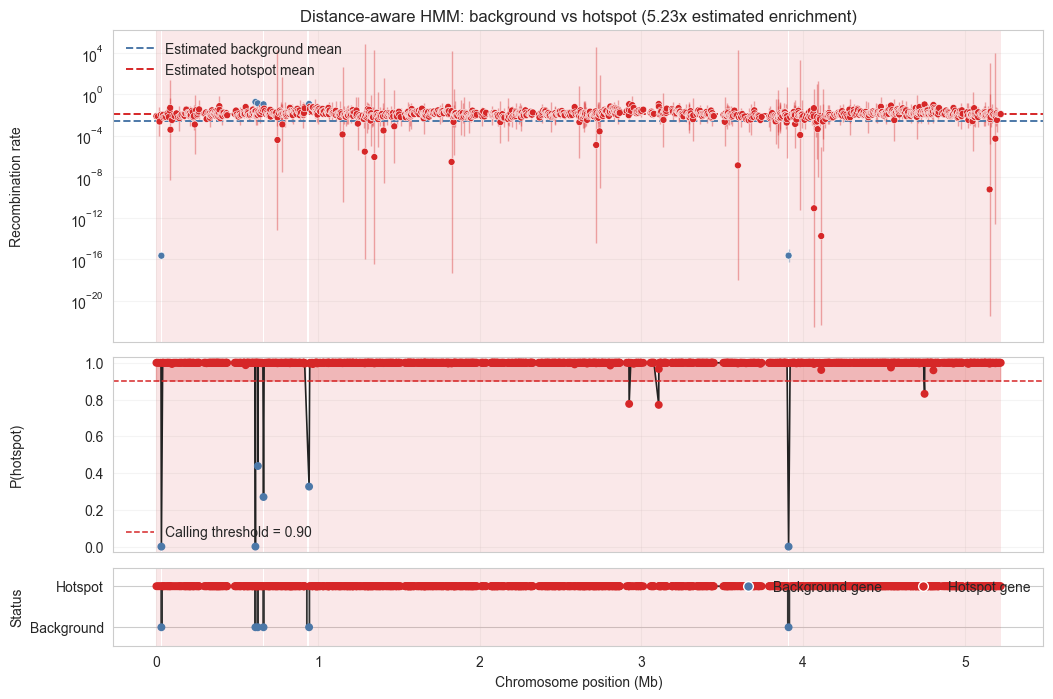

In [108]:
positions = gene_starts[ord_start_pos]

# global_log_rate1 = np.log(0.017)
# global_log_rate2 = np.log(median_rho)

posterior_rate_draws = theta_post[ord_start_pos, :, 0]
indices_below_zero = np.where(posterior_rate_draws <= 0)
posterior_rate_draws[indices_below_zero] = np.finfo(np.float64).eps

model = DistanceAwareHotspotHMM(
    distance_unit_bp=1e5,
    min_log_fold=np.log(5.0),
    n_starts=10,
    random_state=11,
)
result = model.fit(positions, posterior_samples=posterior_rate_draws)

print(f"Estimated fold enrichment: {result.fold_enrichment:.2f}x")
print(f"Expected hotspot length: {result.expected_hotspot_length:,.0f} bp")

# Plot rates, posterior hotspot probabilities, and the two-state path.
result.plot_states(
    probability_threshold=0.90,
    position_unit_bp=1e6,
    position_unit_name="Mb",
    rate_label="Recombination rate",
    save_path="hmm_hotspot_states.png",
)

import matplotlib.pyplot as plt
plt.show()

In [109]:
"""Difference-of-Gaussians hotspot detection for irregularly spaced genes.

The detector treats gene-level log rates as a one-dimensional genomic signal.
It subtracts a broad Gaussian smoother (background) from a narrow Gaussian
smoother (local signal), then propagates NPE uncertainty by applying the
filter to posterior draws.

This is an exploratory posterior-stability method, not a formally coherent
chromosome-level Bayesian model. Calibrate detection thresholds using
end-to-end chromosomes simulated under a no-hotspot model.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import numpy as np
from numpy.typing import ArrayLike


_EPS = 1e-12

In [126]:
def _weighted_gaussian_matrix(
    source_positions: np.ndarray,
    target_positions: np.ndarray,
    bandwidth_bp: float,
    precision: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Return normalized uncertainty-weighted Gaussian smoothing matrix."""
    distance = target_positions[:, None] - source_positions[None, :]
    kernel = np.exp(-0.5 * (distance / bandwidth_bp) ** 2)
    weighted = kernel * precision[None, :]
    support = weighted.sum(axis=1)
    matrix = weighted / np.maximum(support[:, None], _EPS)

    # Kish effective sample size, useful for diagnosing unsupported locations.
    effective_n = support**2 / np.maximum((weighted**2).sum(axis=1), _EPS)
    return matrix, effective_n


@dataclass
class DoGHotspotResult:
    """Results from uncertainty-aware Difference-of-Gaussians filtering."""

    positions_bp: np.ndarray
    posterior_rate_median: np.ndarray
    posterior_rate_lower: np.ndarray
    posterior_rate_upper: np.ndarray
    narrow_rate_median: np.ndarray
    broad_rate_median: np.ndarray
    dog_log_enrichment_median: np.ndarray
    dog_log_enrichment_lower: np.ndarray
    dog_log_enrichment_upper: np.ndarray
    hotspot_probability: np.ndarray
    hotspot_call: np.ndarray
    narrow_effective_n: np.ndarray
    broad_effective_n: np.ndarray
    narrow_bandwidth_bp: float
    broad_bandwidth_bp: float
    min_fold_enrichment: float
    probability_threshold: float
    sort_order: np.ndarray

    @property
    def local_fold_enrichment_median(self) -> np.ndarray:
        """Median narrow-scale/broad-scale fold enrichment."""
        return np.exp(self.dog_log_enrichment_median)

    def segments(self, max_gap_bp: Optional[float] = None) -> list[dict]:
        """Return contiguous called regions, optionally split across large gaps."""
        if max_gap_bp is None:
            max_gap_bp = 2.0 * self.narrow_bandwidth_bp
        if max_gap_bp <= 0:
            raise ValueError("max_gap_bp must be positive")

        segments: list[dict] = []
        start: Optional[int] = None
        n = len(self.positions_bp)

        for i in range(n):
            starts_new = self.hotspot_call[i] and (
                i == 0
                or not self.hotspot_call[i - 1]
                or self.positions_bp[i] - self.positions_bp[i - 1] > max_gap_bp
            )
            if starts_new:
                start = i

            ends_here = self.hotspot_call[i] and (
                i == n - 1
                or not self.hotspot_call[i + 1]
                or self.positions_bp[i + 1] - self.positions_bp[i] > max_gap_bp
            )
            if ends_here and start is not None:
                sl = slice(start, i + 1)
                segments.append(
                    {
                        "start_index": start,
                        "end_index": i,
                        "start_position_bp": float(self.positions_bp[start]),
                        "end_position_bp": float(self.positions_bp[i]),
                        "n_genes": i - start + 1,
                        "peak_probability": float(self.hotspot_probability[sl].max()),
                        "median_probability": float(np.median(self.hotspot_probability[sl])),
                        "peak_fold_enrichment": float(
                            self.local_fold_enrichment_median[sl].max()
                        ),
                    }
                )
                start = None
        return segments

    def plot(
        self,
        rate_label: str = "Recombination rate",
        position_unit_bp: float = 1e6,
        position_unit_name: str = "Mb",
        max_gap_bp: Optional[float] = None,
        figsize: tuple[float, float] = (12.0, 9.0),
        save_path: Optional[str] = None,
        dpi: int = 300,
    ):
        """Plot gene rates, DoG enrichment, and hotspot probability."""
        import matplotlib.pyplot as plt

        if position_unit_bp <= 0:
            raise ValueError("position_unit_bp must be positive")

        x = self.positions_bp / position_unit_bp
        fig, axes = plt.subplots(
            3,
            1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": [3.0, 2.1, 1.8], "hspace": 0.08},
        )
        ax_rate, ax_dog, ax_prob = axes

        # Shade called regions on all panels.
        for segment in self.segments(max_gap_bp=max_gap_bp):
            i0, i1 = segment["start_index"], segment["end_index"]
            left = x[i0] if i0 == 0 else 0.5 * (x[i0 - 1] + x[i0])
            right = x[i1] if i1 == len(x) - 1 else 0.5 * (x[i1] + x[i1 + 1])
            for ax in axes:
                ax.axvspan(left, right, color="#d62728", alpha=0.10, lw=0)

        colors = np.where(self.hotspot_call, "#d62728", "#4c78a8")
        ax_rate.vlines(
            x,
            self.posterior_rate_lower,
            self.posterior_rate_upper,
            color=colors,
            alpha=0.28,
            linewidth=0.8,
        )
        ax_rate.scatter(
            x,
            self.posterior_rate_median,
            c=colors,
            s=18,
            edgecolor="white",
            linewidth=0.3,
            zorder=3,
            label="Gene posterior median",
        )
        ax_rate.plot(
            x,
            self.narrow_rate_median,
            color="#e68613",
            linewidth=1.7,
            label=f"Narrow smoother ({self.narrow_bandwidth_bp / 1e3:g} kb)",
        )
        ax_rate.plot(
            x,
            self.broad_rate_median,
            color="#222222",
            linewidth=1.7,
            label=f"Broad background ({self.broad_bandwidth_bp / 1e3:g} kb)",
        )
        ax_rate.set_yscale("linear")
        ax_rate.set_ylabel(rate_label)
        ax_rate.set_title("Uncertainty-aware Difference-of-Gaussians hotspot detection")
        ax_rate.grid(alpha=0.2)
        ax_rate.legend(frameon=False, ncol=3, fontsize=9)

        fold_median = np.exp(self.dog_log_enrichment_median)
        fold_lower = np.exp(self.dog_log_enrichment_lower)
        fold_upper = np.exp(self.dog_log_enrichment_upper)
        ax_dog.fill_between(
            x, fold_lower, fold_upper, color="#7f7f7f", alpha=0.22, label="95% interval"
        )
        ax_dog.plot(x, fold_median, color="#7b3294", linewidth=1.6)
        ax_dog.axhline(1.0, color="#555555", linestyle=":", linewidth=1.0)
        ax_dog.axhline(
            self.min_fold_enrichment,
            color="#d62728",
            linestyle="--",
            linewidth=1.2,
            label=f"Minimum enrichment = {self.min_fold_enrichment:g}x",
        )
        ax_dog.set_yscale("log")
        ax_dog.set_ylabel("Local / broad\nfold enrichment")
        ax_dog.grid(alpha=0.2)
        ax_dog.legend(frameon=False, loc="upper right")

        ax_prob.plot(x, self.hotspot_probability, color="#222222", linewidth=1.4)
        ax_prob.scatter(x, self.hotspot_probability, c=colors, s=18, zorder=3)
        ax_prob.fill_between(
            x,
            self.probability_threshold,
            self.hotspot_probability,
            where=self.hotspot_probability >= self.probability_threshold,
            color="#d62728",
            alpha=0.28,
            interpolate=True,
        )
        ax_prob.axhline(
            self.probability_threshold,
            color="#d62728",
            linestyle="--",
            linewidth=1.2,
            label=f"Calling threshold = {self.probability_threshold:g}",
        )
        ax_prob.set_ylim(-0.03, 1.03)
        ax_prob.set_ylabel("P(enrichment\nexceeds threshold)")
        ax_prob.set_xlabel(f"Chromosome position ({position_unit_name})")
        ax_prob.grid(alpha=0.2)
        ax_prob.legend(frameon=False, loc="upper right")

        fig.subplots_adjust(left=0.10, right=0.98, bottom=0.08, top=0.94, hspace=0.08)
        if save_path is not None:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        return fig, axes


class DifferenceOfGaussiansHotspotDetector:
    """Detect local rate elevations relative to a broad genomic background.

    Parameters
    ----------
    narrow_bandwidth_bp
        Gaussian bandwidth for the local signal. Choose this near the
        expected hotspot radius, not its full width.
    broad_bandwidth_bp
        Gaussian bandwidth for the background. It must be larger than the
        narrow bandwidth, commonly by a factor of 4 to 10.
    min_fold_enrichment
        A location is considered enriched in a posterior draw when the
        narrow smoother exceeds the broad smoother by at least this factor.
    probability_threshold
        Minimum posterior-draw frequency used to call a hotspot.
    residual_log_sd
        Extra log-rate variability added to each gene's posterior variance
        when constructing smoothing weights. This prevents very precise genes
        from dominating their neighborhoods.
    min_effective_genes
        Locations with fewer than this effective number of genes in either
        smoother are not called, although their scores remain available.
    max_posterior_draws
        Optional random subsample size for computational efficiency.
    random_state
        Seed used only when posterior draws are subsampled.
    """

    def __init__(
        self,
        narrow_bandwidth_bp: float,
        broad_bandwidth_bp: float,
        min_fold_enrichment: float = 1.5,
        probability_threshold: float = 0.90,
        residual_log_sd: float = 0.20,
        min_effective_genes: float = 2.0,
        max_posterior_draws: Optional[int] = 5000,
        random_state: Optional[int] = 0,
    ):
        if narrow_bandwidth_bp <= 0:
            raise ValueError("narrow_bandwidth_bp must be positive")
        if broad_bandwidth_bp <= narrow_bandwidth_bp:
            raise ValueError("broad_bandwidth_bp must exceed narrow_bandwidth_bp")
        if min_fold_enrichment <= 1:
            raise ValueError("min_fold_enrichment must exceed 1")
        if not 0 < probability_threshold < 1:
            raise ValueError("probability_threshold must be between 0 and 1")
        if residual_log_sd < 0:
            raise ValueError("residual_log_sd cannot be negative")
        if min_effective_genes <= 0:
            raise ValueError("min_effective_genes must be positive")
        if max_posterior_draws is not None and max_posterior_draws < 2:
            raise ValueError("max_posterior_draws must be at least 2")

        self.narrow_bandwidth_bp = float(narrow_bandwidth_bp)
        self.broad_bandwidth_bp = float(broad_bandwidth_bp)
        self.min_fold_enrichment = float(min_fold_enrichment)
        self.probability_threshold = float(probability_threshold)
        self.residual_log_sd = float(residual_log_sd)
        self.min_effective_genes = float(min_effective_genes)
        self.max_posterior_draws = max_posterior_draws
        self.random_state = random_state

    def fit(
        self,
        positions_bp: ArrayLike,
        posterior_draws: ArrayLike,
        rates_are_log: bool = False,
    ) -> DoGHotspotResult:
        """Apply the DoG filter to gene-level posterior draws.

        Parameters
        ----------
        positions_bp
            One genomic coordinate per gene, typically gene midpoint.
        posterior_draws
            Array with shape (n_draws, n_genes). Pass joint NPE draws for one
            parameter at a time, preserving each gene's posterior uncertainty.
        rates_are_log
            Set True if posterior_draws already contain natural-log rates.

        Returns
        -------
        DoGHotspotResult
            Arrays are sorted by genomic position.
        """
        positions = np.asarray(positions_bp, dtype=float)
        draws = np.asarray(posterior_draws, dtype=float)

        if positions.ndim != 1:
            raise ValueError("positions_bp must be one-dimensional")
        if draws.ndim != 2:
            raise ValueError("posterior_draws must have shape (n_draws, n_genes)")
        if draws.shape[1] != len(positions):
            raise ValueError("posterior_draws columns must match positions_bp")
        if draws.shape[0] < 2:
            raise ValueError("At least two posterior draws are required")
        if not np.all(np.isfinite(positions)) or not np.all(np.isfinite(draws)):
            raise ValueError("positions_bp and posterior_draws must be finite")
        if len(np.unique(positions)) != len(positions):
            raise ValueError("Gene positions must be unique")
        if not rates_are_log and np.any(draws <= 0):
            raise ValueError("Rates must be positive when rates_are_log=False")

        order = np.argsort(positions)
        positions = positions[order]
        draws = draws[:, order]

        if (
            self.max_posterior_draws is not None
            and draws.shape[0] > self.max_posterior_draws
        ):
            rng = np.random.default_rng(self.random_state)
            selected = rng.choice(
                draws.shape[0], size=self.max_posterior_draws, replace=False
            )
            draws = draws[selected]

        log_draws = draws if rates_are_log else np.log(draws)
        posterior_log_variance = np.var(log_draws, axis=0, ddof=1)
        precision = 1.0 / (
            posterior_log_variance + self.residual_log_sd**2 + _EPS
        )

        narrow_matrix, narrow_effective_n = _weighted_gaussian_matrix(
            positions, positions, self.narrow_bandwidth_bp, precision
        )
        broad_matrix, broad_effective_n = _weighted_gaussian_matrix(
            positions, positions, self.broad_bandwidth_bp, precision
        )

        narrow_log_draws = log_draws @ narrow_matrix.T
        broad_log_draws = log_draws @ broad_matrix.T
        dog_draws = narrow_log_draws - broad_log_draws

        threshold = np.log(self.min_fold_enrichment)
        hotspot_probability = np.mean(dog_draws > threshold, axis=0)
        adequate_support = (
            (narrow_effective_n >= self.min_effective_genes)
            & (broad_effective_n >= self.min_effective_genes)
        )
        hotspot_call = (
            hotspot_probability >= self.probability_threshold
        ) & adequate_support

        rate_draws = np.exp(log_draws)
        rate_q = np.quantile(rate_draws, [0.025, 0.5, 0.975], axis=0)
        dog_q = np.quantile(dog_draws, [0.025, 0.5, 0.975], axis=0)

        return DoGHotspotResult(
            positions_bp=positions,
            posterior_rate_median=rate_q[1],
            posterior_rate_lower=rate_q[0],
            posterior_rate_upper=rate_q[2],
            narrow_rate_median=np.exp(np.median(narrow_log_draws, axis=0)),
            broad_rate_median=np.exp(np.median(broad_log_draws, axis=0)),
            dog_log_enrichment_median=dog_q[1],
            dog_log_enrichment_lower=dog_q[0],
            dog_log_enrichment_upper=dog_q[2],
            hotspot_probability=hotspot_probability,
            hotspot_call=hotspot_call,
            narrow_effective_n=narrow_effective_n,
            broad_effective_n=broad_effective_n,
            narrow_bandwidth_bp=self.narrow_bandwidth_bp,
            broad_bandwidth_bp=self.broad_bandwidth_bp,
            min_fold_enrichment=self.min_fold_enrichment,
            probability_threshold=self.probability_threshold,
            sort_order=order,
        )


def simulate_example(
    n_genes: int = 260,
    n_posterior_draws: int = 3000,
    chromosome_length_bp: float = 30e6,
    random_state: int = 7,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate irregular gene positions and uncertain gene-level rate posteriors."""
    rng = np.random.default_rng(random_state)
    positions = np.sort(rng.uniform(0, chromosome_length_bp, n_genes))

    # Slowly varying background plus two local elevations of different widths.
    broad_background = (
        np.log(1.0)
        + 0.18 * np.sin(2.0 * np.pi * positions / chromosome_length_bp)
        + 0.10 * np.cos(4.0 * np.pi * positions / chromosome_length_bp)
    )
    hotspot_1 = np.log(3.2) * np.exp(
        -0.5 * ((positions - 8.5e6) / 0.40e6) ** 2
    )
    hotspot_2 = np.log(2.3) * np.exp(
        -0.5 * ((positions - 21.5e6) / 0.85e6) ** 2
    )
    true_log_rate = broad_background + hotspot_1 + hotspot_2

    # Mimic heterogeneous NPE uncertainty and slight gene-level estimation error.
    posterior_log_sd = rng.uniform(0.12, 0.38, n_genes)
    posterior_center = true_log_rate + rng.normal(0.0, 0.10, n_genes)
    log_draws = rng.normal(
        posterior_center[None, :],
        posterior_log_sd[None, :],
        size=(n_posterior_draws, n_genes),
    )
    return positions, np.exp(log_draws), np.exp(true_log_rate)

Detected hotspot segments:
  0.18-0.20 Mb; 6 genes; peak P=1.000; peak enrichment=2.25x
  0.22-0.22 Mb; 1 genes; peak P=0.977; peak enrichment=1.50x
  0.25-0.25 Mb; 1 genes; peak P=0.942; peak enrichment=1.52x
  0.26-0.26 Mb; 3 genes; peak P=0.961; peak enrichment=1.67x
  0.48-0.49 Mb; 3 genes; peak P=1.000; peak enrichment=1.80x
  0.55-0.56 Mb; 4 genes; peak P=1.000; peak enrichment=2.05x
  0.59-0.64 Mb; 20 genes; peak P=1.000; peak enrichment=3.06x
  0.65-0.67 Mb; 7 genes; peak P=1.000; peak enrichment=4.15x
  0.77-0.77 Mb; 1 genes; peak P=0.925; peak enrichment=1.50x
  0.81-0.84 Mb; 12 genes; peak P=1.000; peak enrichment=1.99x
  0.85-0.88 Mb; 8 genes; peak P=1.000; peak enrichment=2.02x
  0.91-0.92 Mb; 3 genes; peak P=0.999; peak enrichment=2.15x
  0.95-1.04 Mb; 25 genes; peak P=1.000; peak enrichment=5.52x
  1.06-1.07 Mb; 9 genes; peak P=0.999; peak enrichment=1.85x
  1.58-1.58 Mb; 1 genes; peak P=0.946; peak enrichment=1.40x
  1.64-1.65 Mb; 5 genes; peak P=0.998; peak enrichment=

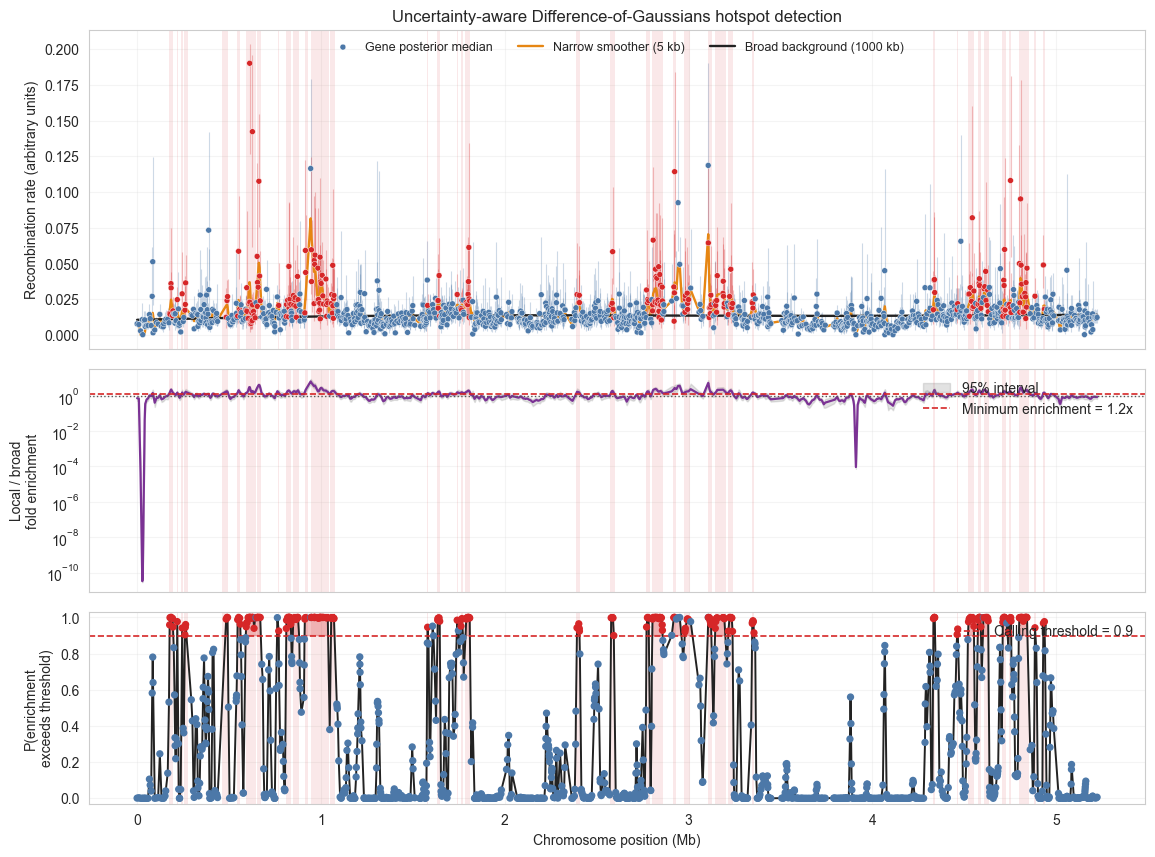

In [132]:
import matplotlib.pyplot as plt

positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 0].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DifferenceOfGaussiansHotspotDetector(
    narrow_bandwidth_bp=5_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=1.2,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=2.5,
    random_state=11,
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Recombination rate (arbitrary units)",
    save_path="dog_hotspot_example.png",
)
plt.show()